In [1]:
import urllib.request, gzip, numpy as np

base = "https://raw.githubusercontent.com/gagolews/clustering-data-v1/master/sipu/"
for name in ["unbalance.data.gz", "unbalance.labels0.gz"]:
    urllib.request.urlretrieve(base + name, name)
    with gzip.open(name, 'rt') as fin:
        open(name[:-3], 'w').write(fin.read())

# 이후 위 변환 코드 실행

In [3]:
import numpy as np

X = np.loadtxt('unbalance.data')           # 6500 x 2 좌표
y = np.loadtxt('unbalance.labels0').astype(int)  # 6500 라벨 (1~8)
N = len(X)

header = """% Unbalance dataset (SIPU, University of Eastern Finland)
% Source: P. Franti et al., http://cs.joensuu.fi/sipu/datasets/
% Rezaei & Franti (2016), Set matching measures for external cluster
%   validity, IEEE TKDE 28(8):2173-2186.
%
% N=6500, dim=2, 8 clusters
% 3 large clusters (size 2000) + 5 small clusters (size 100)
% Clusters differ in density.
%
@RELATION unbalance

@ATTRIBUTE x REAL
@ATTRIBUTE y REAL
@ATTRIBUTE class {1,2,3,4,5,6,7,8}

@DATA
"""

with open('unbalance.arff', 'w') as f:
    f.write(header)
    for i in range(N):
        f.write(f"{X[i,0]:.0f},{X[i,1]:.0f},{y[i]}\n")

print(f"unbalance.arff 생성 완료: {N}개 데이터")

unbalance.arff 생성 완료: 6500개 데이터


✅ 이미 존재하는 파일 사용: target.arff
원본 레이블 분포:
  Class 1: 395 points
  Class 2: 363 points
  Class 3: 3 points
  Class 4: 3 points
  Class 5: 3 points
  Class 6: 3 points

변환 후 레이블 분포:
  Class -1: 12 points (noise)
  Class 1: 395 points 
  Class 2: 363 points 

✅ 저장 완료: fcps_target_scatter_noise.png


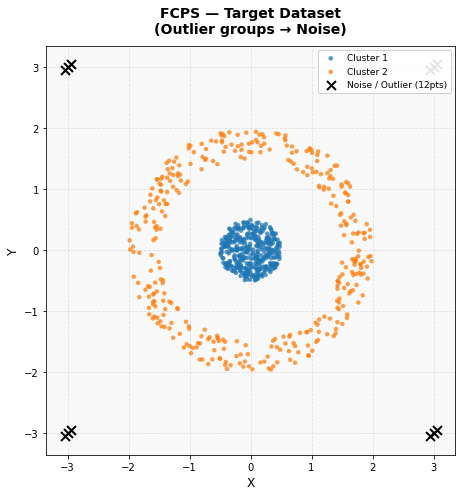

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import os

ARFF_URL  = "https://raw.githubusercontent.com/deric/clustering-benchmark/master/src/main/resources/datasets/artificial/target.arff"
SAVE_PATH = "target.arff"

if not os.path.exists(SAVE_PATH):
    print(f"다운로드 중: {ARFF_URL}")
    urllib.request.urlretrieve(ARFF_URL, SAVE_PATH)
    print(f"✅ 저장 완료: {SAVE_PATH}")
else:
    print(f"✅ 이미 존재하는 파일 사용: {SAVE_PATH}")


def load_arff(filepath):
    coords, labels = [], []
    data_section = False
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('%'):
                continue
            if line.lower().startswith('@data'):
                data_section = True
                continue
            if data_section:
                line = line.replace('\t', ' ').replace(',', ' ')
                values = line.split()
                if len(values) < 2:
                    continue
                coords.append([float(v) for v in values[:-1]])
                try:
                    labels.append(int(values[-1]))
                except ValueError:
                    labels.append(str(values[-1]))
    return np.array(coords, dtype=np.float64), np.array(labels)


pts, raw_labels = load_arff(SAVE_PATH)

# ---------------------------------------------------------
# 핵심: 클래스 분포 확인 후 small outlier 그룹을 -1로 변환
# ---------------------------------------------------------
unique, counts = np.unique(raw_labels, return_counts=True)
print("원본 레이블 분포:")
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} points")

# 포인트 수가 적은 클래스(≤ 10개)를 noise(-1)로 처리
NOISE_THRESHOLD = 10
labels = raw_labels.copy()
for u, c in zip(unique, counts):
    if c <= NOISE_THRESHOLD:
        labels[labels == u] = -1

print("\n변환 후 레이블 분포:")
for u, c in zip(*np.unique(labels, return_counts=True)):
    tag = "(noise)" if u == -1 else ""
    print(f"  Class {u}: {c} points {tag}")

X, Y = pts[:, 0], pts[:, 1]

# ---------------------------------------------------------
# Scatter Plot
# ---------------------------------------------------------
cmap = plt.get_cmap('tab10')
main_labels = sorted(set(labels) - {-1})
color_map = {label: cmap(i % 10) for i, label in enumerate(main_labels)}

fig, ax = plt.subplots(figsize=(8, 7))

# 메인 클러스터 먼저
for label in main_labels:
    idx = labels == label
    ax.scatter(X[idx], Y[idx],
               color=color_map[label], marker='o', s=20, alpha=0.75,
               edgecolors='none', label=f'Cluster {label}', zorder=2)

# Noise(outlier) 마지막에 위에 덮어서 강조
noise_idx = labels == -1
ax.scatter(X[noise_idx], Y[noise_idx],
           c='black', marker='x', s=80, linewidths=2.0,
           label=f'Noise / Outlier ({noise_idx.sum()}pts)', zorder=4)

ax.set_title("FCPS — Target Dataset\n(Outlier groups → Noise)", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("X", fontsize=12)
ax.set_ylabel("Y", fontsize=12)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.35)
ax.set_facecolor('#f9f9f9')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("fcps_target_scatter_noise.png", dpi=300, bbox_inches='tight')
print("\n✅ 저장 완료: fcps_target_scatter_noise.png")
plt.show()